<a href="https://colab.research.google.com/github/sapnasingh02/CODSOFT_TASKSNO/blob/main/Copy_of_Sales_Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Prediction Using Python

### CodSoft Data Science Internship

**Task:** Task 4 - Sales Prediction Using Python  
**Domain:** Data Science / Machine Learning  
**Algorithm:** Linear Regression  
**Platform:** Google Colab

## 1. Introduction

Sales prediction is an important application of Data Science and Machine Learning in business.

The objective of this project is to develop a Machine Learning model that can predict product sales based on advertising expenditure.

The dataset contains advertising expenditure for different media channels, including TV, Radio, and Newspaper, along with the corresponding Sales.

In this project, the dataset is explored and visualized to understand the relationship between advertising expenditure and sales. A Linear Regression model is then trained using the advertising data.

The trained model is evaluated using Mean Squared Error and R² Score. Finally, the model is used to predict sales for a new advertising budget.

## 2. Objective

The main objectives of this project are:

1. To understand the relationship between advertising expenditure and sales.
2. To explore and analyze the advertising dataset.
3. To visualize the relationship between advertising channels and sales.
4. To prepare the data for Machine Learning.
5. To divide the data into training and testing datasets.
6. To train a Linear Regression model.
7. To predict sales using advertising expenditure.
8. To evaluate the performance of the model.

## 3. Technologies and Libraries Used

### Programming Language
- Python

### Platform
- Google Colab

### Libraries
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

### Machine Learning Algorithm
- Linear Regression

## 4. Dataset Description

The Advertising dataset contains information about advertising expenditure and product sales.

The main variables are:

- TV: Advertising expenditure through TV.
- Radio: Advertising expenditure through Radio.
- Newspaper: Advertising expenditure through Newspaper.
- Sales: Product sales.

TV, Radio, and Newspaper are used as input features, while Sales is used as the target variable.

The dataset contains 200 observations and is commonly used to demonstrate regression analysis and Machine Learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
url = "https://www.statlearning.com/s/Advertising.csv"

df = pd.read_csv(url)

# Remove unnecessary index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop("Unnamed: 0", axis=1)

# Standardize column names
df.columns = [column.strip().title() for column in df.columns]

print("Dataset loaded successfully!")
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)

Dataset loaded successfully!
Columns: ['Tv', 'Radio', 'Newspaper', 'Sales']
Shape: (200, 4)


## 5. Dataset Exploration

The dataset is explored to understand its structure, number of observations, available variables, and data quality.

This step helps identify missing values and provides an overview of the dataset before applying Machine Learning.

In [ ]:
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Tv,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [ ]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Tv         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Tv           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [ ]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,Tv,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## 6. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the relationship between advertising expenditure and sales.

Scatter plots are used to visualize the relationship between each advertising channel and sales.

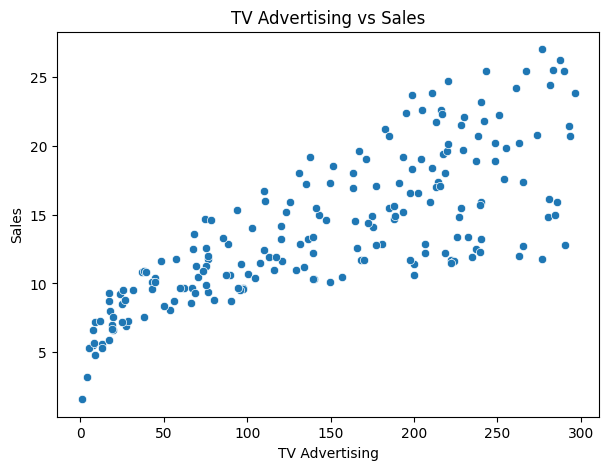

In [ ]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Tv",
    y="Sales"
)

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")

plt.show()

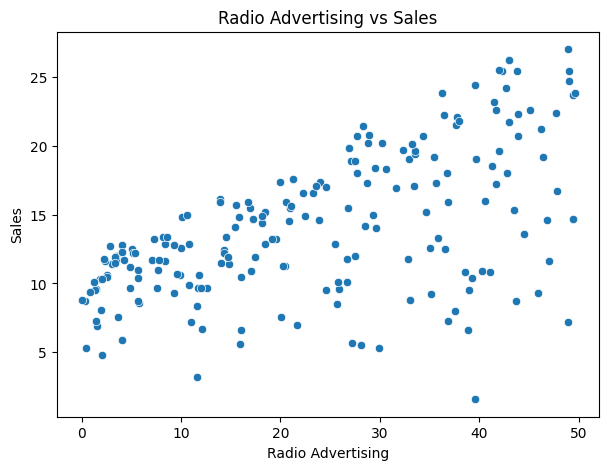

In [ ]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Radio",
    y="Sales"
)

plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")

plt.show()

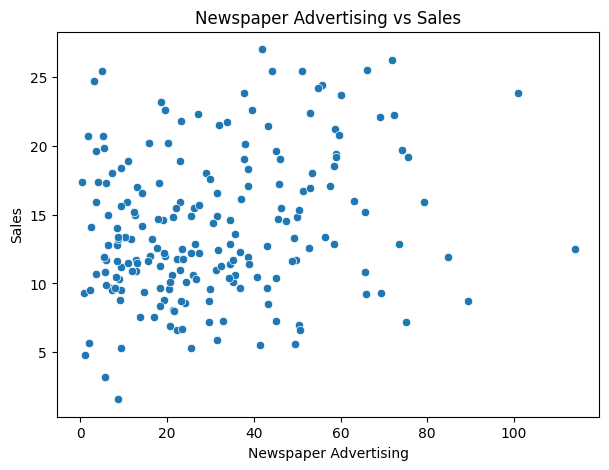

In [ ]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Newspaper",
    y="Sales"
)

plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")

plt.show()

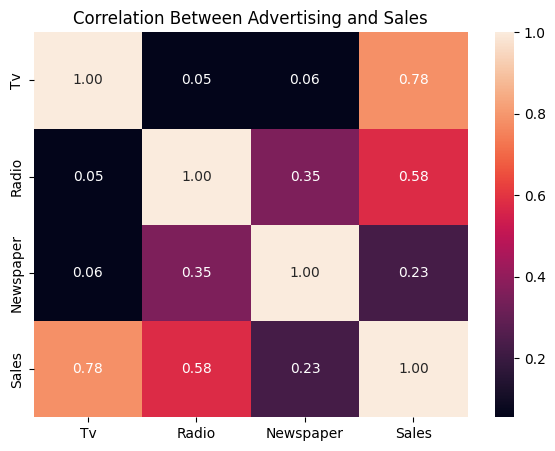

In [ ]:
plt.figure(figsize=(7, 5))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Advertising and Sales")

plt.show()

## 7. Feature and Target Selection

The dataset is divided into input features and a target variable.

### Input Features

- TV Advertising
- Radio Advertising
- Newspaper Advertising

### Target Variable

- Sales

The Machine Learning model learns the relationship between the advertising features and sales.

In [ ]:
X = df[["Tv", "Radio", "Newspaper"]]

y = df["Sales"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,Tv,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4



Target:


,Sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


## 8. Splitting the Dataset

The dataset is divided into training and testing datasets.

- 80% of the data is used for training.
- 20% of the data is used for testing.

The training data is used to train the model, while the testing data is used to evaluate its performance on unseen data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


## 9. Model Training

Linear Regression is used as the Machine Learning algorithm for this project.

Linear Regression is a supervised Machine Learning algorithm used to predict a continuous numerical value.

In this project, the model learns the relationship between TV, Radio, Newspaper advertising expenditure and Sales.

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


## 10. Making Predictions

The trained Linear Regression model is used to predict sales for the testing dataset.

The predicted values are then compared with the actual sales values.

In [ ]:
y_pred = model.predict(X_test)

print("Predicted Sales:")
print(y_pred)

Predicted Sales:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967  9.04831992  6.65328312
 14.34554487  8.90349333  9.68959028 12.16494386  8.73628397 16.26507258
 10.27759582 18.83109103 19.56036653 13.25103464 12.33620695 21.30695132
  7.82740305  5.80957448 20.75753231 11.98138077  9.18349576  8.5066991
 12.46646769 10.00337695 21.3876709  12.24966368 18.26661538 20.13766267
 14.05514005 20.85411186 11.0174441   4.56899622]


## 11. Model Evaluation

The performance of the Linear Regression model is evaluated using two metrics:

### Mean Squared Error (MSE)

Mean Squared Error measures the average squared difference between the actual and predicted values. A lower MSE indicates smaller prediction errors.

### R² Score

R² Score measures how well the model explains the variation in the target variable. A value closer to 1 generally indicates that the model explains more of the variation in the target data.

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 3.1740973539761033
R² Score: 0.899438024100912


## 12. Actual vs Predicted Sales

The actual sales values are compared with the predicted sales values using a scatter plot.

A closer relationship between the actual and predicted values indicates better prediction performance.

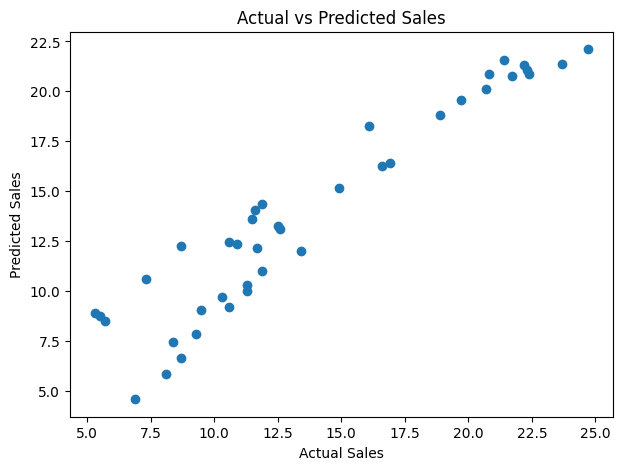

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

## 13. Predicting Sales for a New Advertising Budget

The trained model can be used to predict sales for a new advertising budget.

For demonstration, the following advertising expenditure is provided:

- TV = 150
- Radio = 25
- Newspaper = 20

In [ ]:
new_advertising = pd.DataFrame({
    "Tv": [150],
    "Radio": [25],
    "Newspaper": [20]
})

predicted_sales = model.predict(new_advertising)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 14.473593601116836


## 15. Conclusion

In this project, a Machine Learning model was developed to predict product sales based on advertising expenditure.

The Advertising dataset was explored and analyzed using Python, Pandas, Matplotlib, and Seaborn.

TV, Radio, and Newspaper advertising expenditure were selected as input features, while Sales was selected as the target variable.

The dataset was divided into training and testing sets, and a Linear Regression model was trained using the training data.

The model was evaluated using Mean Squared Error and R² Score. The model was also used to predict sales for a new advertising budget.

This project provided practical experience with data loading, data exploration, data visualization, feature selection, train-test splitting, Machine Learning model training, prediction, and model evaluation.

## 16. Future Scope

This project can be further improved by:

- Testing other Machine Learning algorithms.
- Comparing Linear Regression with Decision Tree and Random Forest models.
- Performing cross-validation.
- Applying feature engineering.
- Using a larger real-world sales dataset.
- Creating an interactive sales prediction dashboard.
- Deploying the model as a web application.

## 17. Project Summary

| Item | Details |
|---|---|
| Project | Sales Prediction Using Python |
| Internship | CodSoft Data Science Internship |
| Task | Task 4 |
| Programming Language | Python |
| Platform | Google Colab |
| Dataset | Advertising Dataset |
| Features | TV, Radio, Newspaper |
| Target | Sales |
| Algorithm | Linear Regression |
| Evaluation Metrics | MSE and R² Score |

## 18. Final Remarks

This project demonstrates a complete Machine Learning workflow for a sales prediction problem.

The workflow includes dataset loading, data exploration, visualization, feature and target selection, train-test splitting, model training, prediction, and evaluation.

The project demonstrates how Machine Learning can be used to analyze advertising expenditure and predict product sales.